# TDBM Replication (IROS 2025 baseline)

Reproduce the **Trajectory-to-Driver-Behavior Mapping (TDBM)** from the paper. Same 6x6 weight matrix `B`, same six ordered classes, on raw AV2/Waymo scenarios.

Per-agent feature vector (paper Eq. 1): `[s_center, v_nei, s_front, v_avg, j_l, 1]`. Per-class score is `B @ feature` and the predicted class is `argmax`. We import the exact `B` from `src/tailrisk_mp/tdbm_style.py` so this notebook stays faithful to the paper's published weights.

Six raw classes (in score order):

| id | label       |
|----|-------------|
| 0  | Aggressive  |
| 1  | Reckless    |
| 2  | Threatening |
| 3  | Careful     |
| 4  | Cautious    |
| 5  | Timid       |

For the side-by-side comparison with our K=2 clustering, we also derive a **binary** TDBM label:

- `aggressive` if raw id in {0, 1, 2} (Aggressive / Reckless / Threatening)
- `normal`     if raw id in {3, 4, 5} (Careful / Cautious / Timid)

**No-neighbor default.** Per the paper, scenes with no valid neighbor for the center agent default to `Threatening` (raw id 2). The shared `compute_style_metrics_from_scene` zero-fills `v_nei` / `s_front` in that case, which would otherwise pull the score toward `Careful`; we override to `Threatening` explicitly when the scene has < 2 valid agents.

Outputs go to `artifacts/tdbm_replication/<dataset>/` so this never collides with our main pipeline or the KDSC outputs.

In [1]:
from __future__ import annotations
import sys, json, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------- DATASET SWITCH --------
DATASET        = 'av2'         # 'av2' or 'waymo'
MAX_SCENARIOS  = None          # set to e.g. 5000 for a fast pass; None = all
PROGRESS_EVERY = 500
# --------------------------------

_CWD = Path.cwd()
for cand in (_CWD, _CWD.parent, _CWD.parent.parent):
    if (cand / 'src').is_dir():
        REPO_ROOT = cand
        break
else:
    REPO_ROOT = _CWD
SRC_ROOT = REPO_ROOT / 'src'
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from tailrisk_mp.runtime import ensure_numpy_pickle_compat
ensure_numpy_pickle_compat()

from tailrisk_mp.tdbm_style import (
    TDBM_RAW_CLASSES,
    compute_behavior_scores,
    compute_style_metrics_from_scene,
)
from tailrisk_mp.scenario_viz import resolve_dataset_dir, _normalize_track_id
from scenarionet.common_utils import read_dataset_summary, read_scenario

if DATASET == 'av2':
    TABLES = REPO_ROOT / 'artifacts' / 'phase1' / 'tables'
    FEAT_CSV = TABLES / 'av2_val_feature_table.csv'
    SPLIT = 'val'
elif DATASET == 'waymo':
    TABLES = REPO_ROOT / 'artifacts' / 'phase1_waymo' / 'tables'
    FEAT_CSV = TABLES / 'waymo_val_feature_table.csv'
    SPLIT = None  # use CATALOG default ('validation')
else:
    raise ValueError(f'DATASET must be "av2" or "waymo", got {DATASET!r}')

OUT_DIR = REPO_ROOT / 'artifacts' / 'tdbm_replication' / DATASET
FIG_DIR = OUT_DIR / 'figures'
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print('Dataset    :', DATASET)
print('Feature CSV:', FEAT_CSV, '| exists:', FEAT_CSV.exists())
print('Outputs    :', OUT_DIR)

Dataset    : av2
Feature CSV: /fs/nexus-projects/pc_driving/yaghoubi/tail-risk-motion-prediction/artifacts/phase1/tables/av2_val_feature_table.csv | exists: True
Outputs    : /fs/nexus-projects/pc_driving/yaghoubi/tail-risk-motion-prediction/artifacts/tdbm_replication/av2


## 1. Load feature table and identify scenarios to process

We only run TDBM on `(scenario_id, center_objects_id)` rows that survive the same minimal cleaning we used in the KDSC replication: vehicle-only, non-stationary, no NaN/inf in the kinematic columns we report on. This keeps TDBM and KDSC labels defined on the same rows for a fair comparison.

In [2]:
REPORT_COLS = ['avg_speed', 'max_abs_accel', 'var_acceleration', 'var_speed', 'gamma']
VEHICLE_TYPE_CODE = 1

feat_raw = pd.read_csv(FEAT_CSV)
print('raw rows :', len(feat_raw))

df = feat_raw.copy()
if 'center_objects_type' in df.columns:
    df = df[pd.to_numeric(df['center_objects_type'], errors='coerce') == VEHICLE_TYPE_CODE]
if 'is_stationary' in df.columns:
    df = df[~df['is_stationary'].astype(bool)]
df = df.dropna(subset=[c for c in REPORT_COLS if c in df.columns])
df = df.reset_index(drop=True)
print('clean rows:', len(df), '| unique scenarios:', df['scenario_id'].nunique())

scenario_to_centers = (
    df.groupby('scenario_id')['center_objects_id']
      .apply(lambda s: [str(x) for x in s])
      .to_dict()
)
scenario_ids = list(scenario_to_centers.keys())
if MAX_SCENARIOS is not None:
    scenario_ids = scenario_ids[:MAX_SCENARIOS]
print('scenarios to process:', len(scenario_ids))

raw rows : 22979
clean rows: 21809 | unique scenarios: 21809
scenarios to process: 21809


## 2. Cached scenario reader

`load_scenario_by_id` re-reads the whole `summary.pkl` on every call. For 30k+ scenarios that is prohibitive. We read summary+mapping **once** here and reuse them.

In [3]:
dataset_dir = resolve_dataset_dir(DATASET, split=SPLIT)
print('dataset dir:', dataset_dir, '| exists:', dataset_dir.exists())

summary, _, mapping = read_dataset_summary(str(dataset_dir))
print('summary entries :', len(summary))
print('mapping entries :', len(mapping))

summary_by_scenario_id = {}
for key, entry in summary.items():
    sid = str(entry.get('scenario_id', entry.get('id', '')))
    if sid:
        summary_by_scenario_id[sid] = key

def resolve_key(scenario_id: str) -> str | None:
    sid = str(scenario_id)
    if sid in mapping and sid in summary:
        return sid
    if sid in mapping:
        return sid
    return summary_by_scenario_id.get(sid)

dataset dir: /fs/nexus-projects/pc_driving/datasets/argoverse2_sn/val | exists: True
summary entries : 24988
mapping entries : 24988


## 3. Build per-scenario inputs and run TDBM

For each scenario:
1. Read it from the ScenarioNet pickle.
2. Stack `position[:, :2]` and `valid` across all tracks into `(N_agents, T, 2)` and `(N_agents, T)`.
3. Call `compute_style_metrics_from_scene` (full trajectory passed as `past`, no future).
4. For each `center_objects_id` requested in this scenario, find its index, take its score row, argmax for raw class, and apply the no-neighbor override.

Saves a per-row TDBM record for every center agent we labelled.

In [4]:
DT = 0.1
NO_NEIGHBOR_RAW_CLASS = 2  # 'Threatening' per paper default

def build_scene_arrays(scenario: dict) -> tuple[np.ndarray, np.ndarray, list[str]]:
    track_ids = list(scenario['tracks'].keys())
    positions = []
    masks = []
    T_max = 0
    for tid in track_ids:
        state = scenario['tracks'][tid]['state']
        pos = np.asarray(state['position'])[:, :2]
        val = np.asarray(state['valid']).reshape(-1).astype(bool)
        positions.append(pos)
        masks.append(val)
        T_max = max(T_max, len(val))
    pos_arr  = np.zeros((len(track_ids), T_max, 2), dtype=np.float32)
    mask_arr = np.zeros((len(track_ids), T_max),   dtype=bool)
    for i, (p, m) in enumerate(zip(positions, masks)):
        pos_arr[i, :len(p)]  = p
        mask_arr[i, :len(m)] = m
    return pos_arr, mask_arr, track_ids

def find_center_index(track_ids: list[str], center_id: str) -> int | None:
    cid_norm = _normalize_track_id(center_id)
    for i, tid in enumerate(track_ids):
        if _normalize_track_id(tid) == cid_norm or str(tid) == str(center_id):
            return i
    return None

rows: list[dict] = []
skipped = {'no_key': 0, 'read_fail': 0, 'center_missing': 0}
t0 = time.time()
for n, sid in enumerate(scenario_ids):
    key = resolve_key(sid)
    if key is None:
        skipped['no_key'] += 1
        continue
    try:
        scenario = read_scenario(str(dataset_dir), mapping, key)
    except Exception:
        skipped['read_fail'] += 1
        continue

    pos_arr, mask_arr, track_ids = build_scene_arrays(scenario)
    metrics = compute_style_metrics_from_scene(pos_arr, mask_arr, dt=DT)
    behavior_scores = np.asarray(metrics['behavior_scores'], dtype=np.float32)
    behavior_type   = np.asarray(metrics['behavior_type'],   dtype=np.int64)
    # Per-agent validity for the no-neighbor default: the agent itself is valid
    # at least once, and at least one OTHER agent is valid at least once.
    any_valid_per_agent = mask_arr.any(axis=1)
    total_valid_agents = int(any_valid_per_agent.sum())

    for center_id in scenario_to_centers.get(sid, []):
        ci = find_center_index(track_ids, center_id)
        if ci is None:
            skipped['center_missing'] += 1
            continue
        has_neighbor = (total_valid_agents - int(any_valid_per_agent[ci])) >= 1
        raw_id = int(behavior_type[ci])
        if not has_neighbor:
            raw_id = NO_NEIGHBOR_RAW_CLASS
        row = {
            'scenario_id':         sid,
            'center_objects_id':   str(center_id),
            'tdbm_raw_style_id':   raw_id,
            'tdbm_raw_style_label': TDBM_RAW_CLASSES[raw_id],
            'tdbm_s_center':       float(metrics['s_center'][ci]),
            'tdbm_v_nei':          float(metrics['v_nei'][ci]),
            'tdbm_s_front':        float(metrics['s_front'][ci]),
            'tdbm_v_avg':          float(metrics['v_avg'][ci]),
            'tdbm_j_l':            float(metrics['j_l'][ci]),
            'tdbm_has_neighbor':   bool(has_neighbor),
        }
        for k in range(6):
            row[f'tdbm_score_{k}'] = float(behavior_scores[ci, k])
        rows.append(row)

    if (n + 1) % PROGRESS_EVERY == 0:
        dt = time.time() - t0
        rate = (n + 1) / dt
        eta = (len(scenario_ids) - (n + 1)) / rate
        print(f'  scenario {n+1}/{len(scenario_ids)}  '
              f'rate={rate:.1f}/s  rows={len(rows)}  '
              f'elapsed={dt/60:.1f}min  eta={eta/60:.1f}min')

print('\ndone. rows produced:', len(rows), '| skipped:', skipped,
      f'| elapsed={(time.time()-t0)/60:.1f}min')

  scenario 500/21809  rate=80.9/s  rows=500  elapsed=0.1min  eta=4.4min
  scenario 1000/21809  rate=84.3/s  rows=1000  elapsed=0.2min  eta=4.1min
  scenario 1500/21809  rate=84.3/s  rows=1500  elapsed=0.3min  eta=4.0min
  scenario 2000/21809  rate=84.0/s  rows=2000  elapsed=0.4min  eta=3.9min
  scenario 2500/21809  rate=83.5/s  rows=2500  elapsed=0.5min  eta=3.9min
  scenario 3000/21809  rate=82.9/s  rows=3000  elapsed=0.6min  eta=3.8min
  scenario 3500/21809  rate=83.1/s  rows=3500  elapsed=0.7min  eta=3.7min
  scenario 4000/21809  rate=83.4/s  rows=4000  elapsed=0.8min  eta=3.6min
  scenario 4500/21809  rate=83.4/s  rows=4500  elapsed=0.9min  eta=3.5min
  scenario 5000/21809  rate=83.7/s  rows=5000  elapsed=1.0min  eta=3.3min
  scenario 5500/21809  rate=83.8/s  rows=5500  elapsed=1.1min  eta=3.2min
  scenario 6000/21809  rate=83.6/s  rows=6000  elapsed=1.2min  eta=3.2min
  scenario 6500/21809  rate=83.7/s  rows=6500  elapsed=1.3min  eta=3.0min
  scenario 7000/21809  rate=83.8/s  rows

## 4. Attach TDBM labels to the feature table

In [5]:
tdbm_df = pd.DataFrame(rows)
tdbm_df['scenario_id']       = tdbm_df['scenario_id'].astype(str)
tdbm_df['center_objects_id'] = tdbm_df['center_objects_id'].astype(str)

feat = df.copy()
feat['scenario_id']       = feat['scenario_id'].astype(str)
feat['center_objects_id'] = feat['center_objects_id'].astype(str)

out = feat.merge(tdbm_df, on=['scenario_id', 'center_objects_id'], how='inner')

# Binary collapse used for the comparison notebook.
AGG_RAW = {0, 1, 2}  # Aggressive / Reckless / Threatening
out['style_label_tdbm'] = np.where(out['tdbm_raw_style_id'].isin(AGG_RAW),
                                    'aggressive', 'normal')

print('rows joined:', len(out))
print('\nraw 6-way distribution:')
print(out['tdbm_raw_style_label'].value_counts())
print('\nbinary distribution:')
print(out['style_label_tdbm'].value_counts())
print('\nno-neighbor default fired:',
      int((~out['tdbm_has_neighbor']).sum()),
      f"({(~out['tdbm_has_neighbor']).mean():.1%})")

rows joined: 21809

raw 6-way distribution:
tdbm_raw_style_label
Careful       21687
Timid           119
Aggressive        3
Name: count, dtype: int64

binary distribution:
style_label_tdbm
normal        21806
aggressive        3
Name: count, dtype: int64

no-neighbor default fired: 0 (0.0%)


## 5. Cluster profile (z-score per raw class)

Same z-score profile we report for KDSC and our main pipeline, but per TDBM raw class so we can see how each of the six bins differs kinematically.

In [6]:
PROFILE_FEATURES = [c for c in [
    'avg_speed', 'max_speed', 'var_speed',
    'max_abs_accel', 'var_acceleration', 'gamma',
    'max_abs_long_accel', 'max_abs_lat_accel',
    'max_abs_jerk', 'max_abs_long_jerk', 'max_abs_lat_jerk',
    'hard_brake_count', 'hard_accel_count',
    'lateral_g_spike_count', 'high_jerk_count',
    'max_abs_heading_rate',
    'tdbm_v_avg', 'tdbm_j_l', 'tdbm_v_nei', 'tdbm_s_front',
] if c in out.columns]

z = (out[PROFILE_FEATURES] - out[PROFILE_FEATURES].mean()) / out[PROFILE_FEATURES].std()
z['tdbm_raw_style_label'] = out['tdbm_raw_style_label']

class_order = ['Aggressive', 'Reckless', 'Threatening', 'Careful', 'Cautious', 'Timid']
present = [c for c in class_order if c in z['tdbm_raw_style_label'].unique()]
profile = z.groupby('tdbm_raw_style_label')[PROFILE_FEATURES].mean().T[present]
profile.to_csv(OUT_DIR / 'tdbm_cluster_profile.csv')
profile.round(3)

tdbm_raw_style_label,Aggressive,Careful,Timid
avg_speed,-0.594,-0.001,0.244
max_speed,-0.165,-0.001,0.238
var_speed,-0.140,0.000,-0.079
max_abs_accel,0.460,-0.000,0.068
var_acceleration,0.324,-0.001,0.116
gamma,0.535,-0.000,0.055
max_abs_long_accel,0.384,-0.000,0.016
max_abs_lat_accel,0.157,-0.002,0.283
max_abs_jerk,0.635,-0.001,0.077
max_abs_long_jerk,0.460,-0.000,0.044


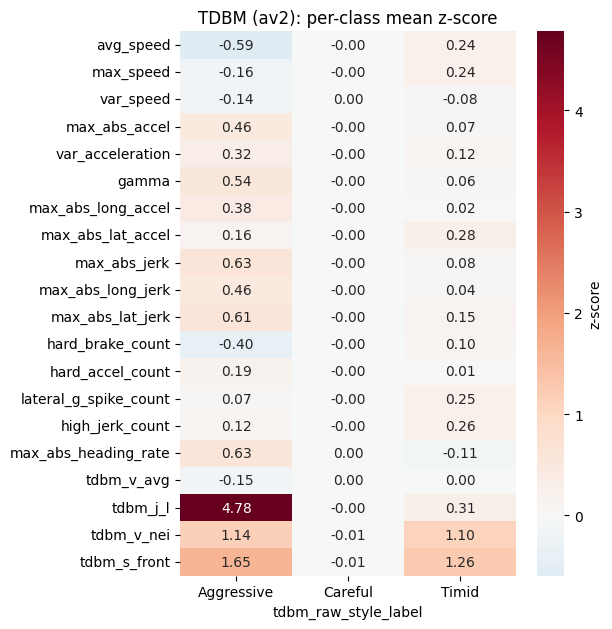

In [7]:
fig, ax = plt.subplots(figsize=(1.4 * len(present) + 2, max(4, 0.32 * len(PROFILE_FEATURES))))
sns.heatmap(profile, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, ax=ax,
            cbar_kws={'label': 'z-score'})
ax.set_title(f'TDBM ({DATASET}): per-class mean z-score')
fig.tight_layout()
fig.savefig(FIG_DIR / 'tdbm_cluster_profile_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

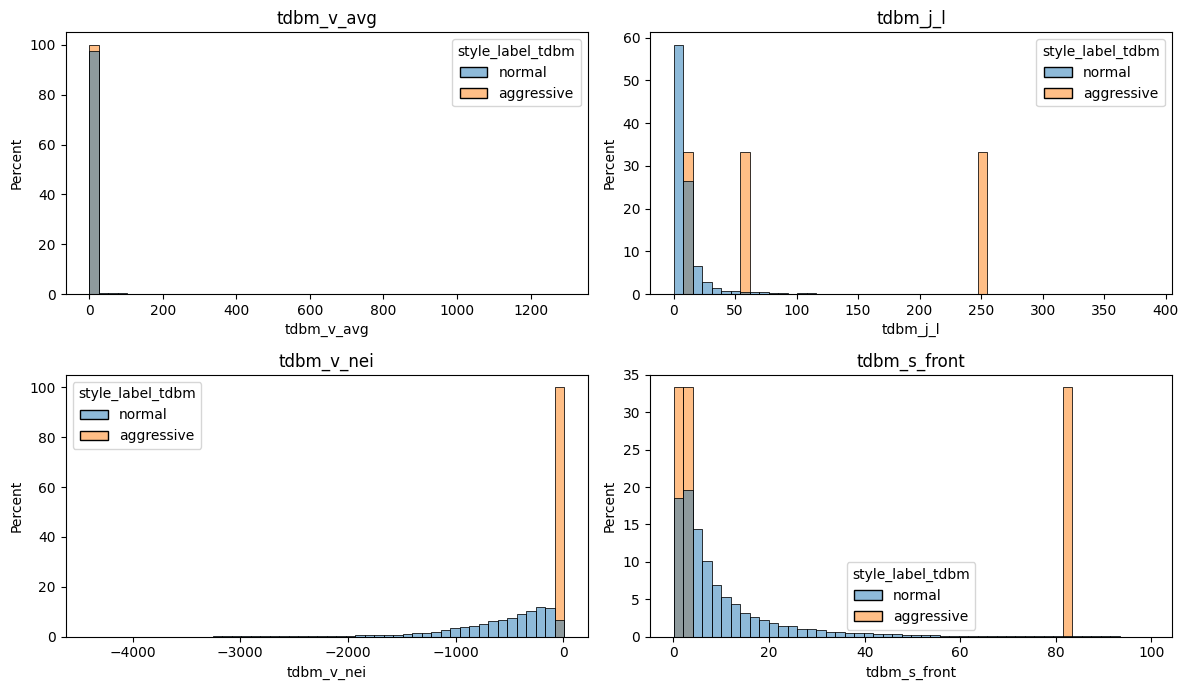

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, feat_col in zip(axes.flat,
                       ['tdbm_v_avg', 'tdbm_j_l', 'tdbm_v_nei', 'tdbm_s_front']):
    if feat_col not in out.columns:
        ax.set_visible(False); continue
    sns.histplot(data=out, x=feat_col, hue='style_label_tdbm',
                 stat='percent', common_norm=False, bins=50, ax=ax)
    ax.set_title(feat_col)
fig.tight_layout()
fig.savefig(FIG_DIR / 'tdbm_feature_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Save labelled table + metrics

In [9]:
out.to_parquet(OUT_DIR / f'{DATASET}_val_tdbm.parquet', index=False)

metrics = {
    'dataset':            DATASET,
    'split':              SPLIT,
    'n_rows':             int(len(out)),
    'n_scenarios':        int(out['scenario_id'].nunique()),
    'scenarios_skipped':  skipped,
    'no_neighbor_default_rate': float((~out['tdbm_has_neighbor']).mean()),
    'raw_class_counts':   out['tdbm_raw_style_label'].value_counts().to_dict(),
    'binary_counts':      out['style_label_tdbm'].value_counts().to_dict(),
    'aggressive_share':   float((out['style_label_tdbm'] == 'aggressive').mean()),
    'paper_weights':      compute_behavior_scores(
                            *[np.zeros(1, dtype=np.float32)] * 5
                          ).tolist(),  # the bias column of B (sanity probe)
}
with open(OUT_DIR / 'tdbm_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print(json.dumps(metrics, indent=2))
print('\nWrote:')
for p in sorted(OUT_DIR.glob('*')):
    print(' ', p.relative_to(REPO_ROOT))

{
  "dataset": "av2",
  "split": "val",
  "n_rows": 21809,
  "n_scenarios": 21809,
  "scenarios_skipped": {
    "no_key": 0,
    "read_fail": 0,
    "center_missing": 0
  },
  "no_neighbor_default_rate": 0.0,
  "raw_class_counts": {
    "Careful": 21687,
    "Timid": 119,
    "Aggressive": 3
  },
  "binary_counts": {
    "normal": 21806,
    "aggressive": 3
  },
  "aggressive_share": 0.000137557888944931,
  "paper_weights": [
    [
      -2.5799999237060547,
      -1.6699999570846558,
      -1.9900000095367432,
      1.3899999856948853,
      1.2699999809265137,
      0.6100000143051147
    ]
  ]
}

Wrote:
  artifacts/tdbm_replication/av2/av2_val_tdbm.parquet
  artifacts/tdbm_replication/av2/figures
  artifacts/tdbm_replication/av2/tdbm_cluster_profile.csv
  artifacts/tdbm_replication/av2/tdbm_metrics.json
